# 01 — Python GIS Fundamentals & Your First World Map
## พื้นฐาน GIS ด้วย Python และ Google Colab

**กลุ่มผู้เรียน:** ปริญญาตรีปี 3–4 และปริญญาโทปี 1–2 สาขาวิทยาศาสตร์สิ่งแวดล้อม  
**ระดับ:** Beginner  
**ข้อมูลหลัก:** `World_Countries.zip`  
**เครื่องมือ:** GeoPandas · Pandas · Matplotlib · Folium · Shapely

Notebook นี้ออกแบบให้เรียนแบบค่อยเป็นค่อยไป:

$$
\text{Python basics}
\rightarrow
\text{GIS data model}
\rightarrow
\text{GeoDataFrame}
\rightarrow
\text{CRS}
\rightarrow
\text{Inspect}
\rightarrow
\text{Query}
\rightarrow
\text{Map}
\rightarrow
\text{Export}
$$

> **แนวคิดประจำวิชา:** Read the data → Ask a question → Map the answer → Explain what it means

## Learning objectives

เมื่อเรียนจบ Notebook นี้ นิสิตควรสามารถ

1. อธิบายความแตกต่างของ **Point, LineString และ Polygon**
2. อธิบายความแตกต่างระหว่าง **Pandas DataFrame** และ **GeoPandas GeoDataFrame**
3. เปิด Shapefile ด้วย GeoPandas
4. ตรวจ `attributes`, `geometry`, `CRS` และ `spatial extent`
5. ทำ **attribute query**
6. สร้าง static map ด้วย Matplotlib / GeoPandas
7. สร้าง interactive map ด้วย Folium
8. แยกความแตกต่างระหว่าง **reference map, categorical thematic map และ choropleth map**
9. ส่งออกข้อมูลเป็น **Shapefile, GeoPackage, PNG 300 dpi และ HTML**
10. เข้าใจว่าเหตุใดเรายังไม่ควรคำนวณพื้นที่ ระยะทาง หรือ buffer ก่อนตรวจ CRS

## 1. GIS คืออะไร?

GIS ไม่ใช่เพียงการวาดแผนที่ แต่เป็นระบบสำหรับเก็บ จัดการ สอบถาม วิเคราะห์ และสื่อสารข้อมูลที่มีตำแหน่งบนโลก

แนวคิดพื้นฐาน:

$$
GIS = Location + Attributes + Relationships
$$

หรือจำง่าย ๆ ว่า GIS ช่วยตอบคำถาม

- **Where?** — อยู่ที่ไหน?
- **What?** — คืออะไร / มีคุณลักษณะอะไร?
- **How are they related?** — มีความสัมพันธ์เชิงพื้นที่กันอย่างไร?

ตัวอย่าง:

| คำถาม | GIS concept |
|---|---|
| ประเทศไทยอยู่ที่ไหน? | Geometry / Location |
| ชื่อประเทศคืออะไร? | Attribute |
| ประเทศไทยอยู่ในทวีปอะไร? | Attribute query |
| ประเทศไทยติดประเทศใดบ้าง? | Spatial relationship |
| ประเทศไทยมีพื้นที่เท่าไร? | Spatial measurement |

## 2. Vector และ Raster

ข้อมูล GIS แบ่งอย่างง่ายได้เป็น 2 กลุ่มใหญ่

| Vector | Raster |
|---|---|
| เก็บเป็น Point / Line / Polygon | เก็บเป็น Grid / Pixel |
| หมู่บ้าน | ภาพดาวเทียม |
| ถนน / แม่น้ำ | DEM |
| จังหวัด / ประเทศ | ฝน อุณหภูมิ PM2.5 แบบกริด |

Notebook 01–08 ของชุดนี้จะเริ่มจาก **Vector GIS** ก่อน เพื่อให้นิสิตเข้าใจโครงสร้างข้อมูลและ spatial operations อย่างเป็นลำดับ

## 3. Point, LineString และ Polygon

### Point

ตำแหน่งหนึ่งจุดเขียนอย่างง่ายเป็น

$$
P=(x,y)
$$

ตัวอย่าง: สถานีตรวจอากาศ โรงเรียน หมู่บ้าน

### LineString

เส้นประกอบด้วยจุดหลายจุดเรียงต่อกัน

$$
L=[P_1,P_2,\ldots,P_n]
$$

ตัวอย่าง: ถนน แม่น้ำ เส้นทาง

### Polygon

พื้นที่ปิดที่มีขอบเขต เช่น จังหวัด ประเทศ พื้นที่ป่า

แนวคิดอย่างง่ายคือจุดเริ่มต้นและจุดสิ้นสุดของขอบเขตปิดต้องกลับมาบรรจบกัน

$$
P_1=P_n
$$

## 4. Python พื้นฐานที่จำเป็น

เราไม่ได้เรียน Python ทั้งภาษาในวันนี้ แต่จะใช้เฉพาะสิ่งที่จำเป็นต่อ GIS ก่อน

**Variable** คือชื่อที่ใช้เก็บค่า

In [1]:
country = "Thailand"
year = 2026
latitude = 15.87

print(country)
print(year)
print(latitude)

Thailand
2026
15.87


### List และ Dictionary

- `list` ใช้เก็บหลายค่าเรียงกัน
- `dictionary` ใช้เก็บข้อมูลแบบ `key : value`

In [2]:
countries = ["Thailand", "Japan", "Vietnam"]

thailand_info = {
    "country": "Thailand",
    "capital": "Bangkok"
}

print(countries)
print(thailand_info)

['Thailand', 'Japan', 'Vietnam']
{'country': 'Thailand', 'capital': 'Bangkok'}


## 5. Pandas vs GeoPandas

Pandas เก็บข้อมูลเป็นตาราง ส่วน GeoPandas เพิ่มข้อมูลเชิงพื้นที่เข้าไป

$$
GeoDataFrame = DataFrame + Geometry + CRS
$$

คิดง่าย ๆ ว่า

```text
หนึ่งแถว (row)
=
หนึ่ง feature
=
attributes + geometry
```

## 6. ติดตั้งและเรียกใช้ libraries

ใน Google Colab บาง library มีอยู่แล้ว แต่เราติดตั้ง/อัปเดต packages ที่จำเป็นเพื่อให้ Notebook ทำงานสม่ำเสมอ

In [3]:
%pip -q install geopandas folium mapclassify matplotlib-scalebar pyogrio

In [4]:
import os
import shutil
import zipfile
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium

from shapely.geometry import Point, LineString, Polygon
from pyproj import Geod
from IPython.display import display

print("GeoPandas :", gpd.__version__)
print("Pandas    :", pd.__version__)
print("Folium    :", folium.__version__)

GeoPandas : 1.2.0
Pandas    : 2.2.3
Folium    : 0.20.0


## 7. เตรียม Font ภาษาไทย

Notebook ต่อ ๆ ไปจะมีชื่อจังหวัด อำเภอ และตำบลภาษาไทย  
เราจึงตั้งค่า **Noto Sans Thai** ตั้งแต่ต้น เพื่อให้ตัวอักษรภาษาไทยแสดงได้ถูกต้องบน Matplotlib

In [37]:
# =========================================================
# Setup Thai font for Matplotlib
# =========================================================

import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

FONT_FILE = "Sarabun-Regular.ttf"

# Download only if the font does not already exist
if not os.path.exists(FONT_FILE):
    !wget -q \
    https://raw.githubusercontent.com/google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf \
    -O Sarabun-Regular.ttf

# Register font with Matplotlib
font_manager.fontManager.addfont(FONT_FILE)

# Read the real font-family name from the file
font_name = font_manager.FontProperties(
    fname=FONT_FILE
).get_name()

# Use it as the default font
mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("Thai font ready:", font_name)

Thai font ready: Sarabun


## 8. สร้าง Geometry ด้วยตัวเองก่อนเปิด Shapefile

เราจะสร้าง Point, LineString และ Polygon ง่าย ๆ เพื่อเห็นว่า GeoPandas เก็บ geometry อย่างไร

In [6]:
p = Point(100.26, 16.82)

line = LineString([
    (100.20, 16.80),
    (100.26, 16.82),
    (100.32, 16.85)
])

polygon = Polygon([
    (100.20, 16.78),
    (100.32, 16.78),
    (100.32, 16.88),
    (100.20, 16.88),
    (100.20, 16.78)
])

demo = gpd.GeoDataFrame(
    {
        "name": ["Point", "LineString", "Polygon"],
        "geometry": [p, line, polygon]
    },
    crs="EPSG:4326"
)

demo

,name,geometry
0,Point,POINT (100.26 16.82)
1,LineString,"LINESTRING (100.2 16.8, 100.26 16.82, 100.32 1..."
2,Polygon,"POLYGON ((100.2 16.78, 100.32 16.78, 100.32 16..."


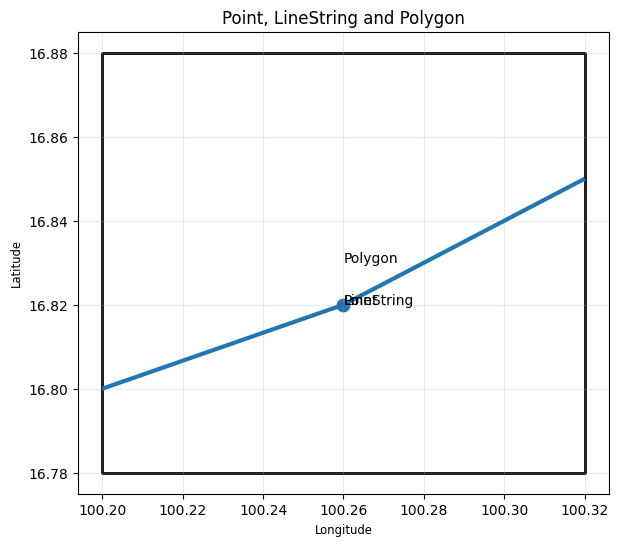

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

demo.iloc[[2]].plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
demo.iloc[[1]].plot(ax=ax, linewidth=3)
demo.iloc[[0]].plot(ax=ax, markersize=80)

for _, row in demo.iterrows():
    rp = row.geometry.representative_point()
    ax.text(rp.x, rp.y, row["name"], fontsize=10)

ax.set_title("Point, LineString and Polygon")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.25)
plt.show()

## 9. Shapefile คืออะไร?

Shapefile **ไม่ใช่ไฟล์เดียว** แต่ประกอบด้วยหลายไฟล์ที่ทำงานร่วมกัน เช่น

```text
.shp  → geometry
.shx  → geometry index
.dbf  → attribute table
.prj  → coordinate reference system
.cpg  → character encoding
```

ดังนั้นชุดข้อมูลจึงมักถูกแจกเป็น ZIP file

## 10. Download ข้อมูล World Countries จาก GitHub

ข้อมูลที่ใช้ในการสอนมาจาก repository:

`nattaponm/thailand_gis_prasertcbs`

ไฟล์:

`world_map/World_Countries.zip`

> URL แบบ `.../blob/...` เป็นหน้าเว็บ GitHub  
> สำหรับ Python เราจะใช้ **raw file URL** เพื่อดาวน์โหลดไฟล์จริง

In [8]:
RAW_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/world_map/World_Countries.zip"
)

DATA_DIR = Path("/content/gis01_data")
OUTPUT_DIR = Path("/content/gis01_outputs")

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

zip_path = DATA_DIR / "World_Countries.zip"

response = requests.get(RAW_URL, timeout=60)
response.raise_for_status()
zip_path.write_bytes(response.content)

print("Downloaded:", zip_path)
print("File size:", round(zip_path.stat().st_size / 1024**2, 2), "MB")

Downloaded: /content/gis01_data/World_Countries.zip
File size: 0.9 MB


## 11. แตก ZIP และตรวจไฟล์ก่อนอ่านข้อมูล

หลักการสำคัญ:

> **Inspect first, analyze later.**

อย่ารีบอ่านไฟล์โดยยังไม่รู้ว่า ZIP มีอะไรอยู่ข้างใน

In [9]:
extract_dir = DATA_DIR / "World_Countries"

if extract_dir.exists():
    shutil.rmtree(extract_dir)

extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

files_inside = sorted(p.relative_to(extract_dir) for p in extract_dir.rglob("*") if p.is_file())

print("Files in ZIP:")
for f in files_inside:
    print(" -", f)

Files in ZIP:
 - World_Countries.dbf
 - World_Countries.prj
 - World_Countries.shp
 - World_Countries.shx


In [10]:
shp_files = list(extract_dir.rglob("*.shp"))

print("Shapefile(s) found:", len(shp_files))
for p in shp_files:
    print(p)

if not shp_files:
    raise FileNotFoundError("ไม่พบไฟล์ .shp ภายใน ZIP")

Shapefile(s) found: 1
/content/gis01_data/World_Countries/World_Countries.shp


## 12. เปิด Shapefile ด้วย GeoPandas

คำสั่งหลักคือ

```python
gpd.read_file(...)
```

ผลลัพธ์เป็น **GeoDataFrame**

In [11]:
world = gpd.read_file(shp_files[0])

print(type(world))
display(world.head())

<class 'geopandas.geodataframe.GeoDataFrame'>


,COUNTRY,ISO,COUNTRYAFF,AFF_ISO,geometry
0,Afghanistan,AF,Afghanistan,AF,"POLYGON ((61.27655 35.60725, 61.37505 35.6361,..."
1,Albania,AL,Albania,AL,"POLYGON ((19.36777 41.849, 19.34333 41.9125, 1..."
2,Algeria,DZ,Algeria,DZ,"POLYGON ((8.62203 36.94136, 8.63805 36.83111, ..."
3,American Samoa,AS,United States,US,None
4,Andorra,AD,Andorra,AD,"POLYGON ((1.44584 42.60194, 1.55972 42.65596, ..."


## 13. อ่านตารางก่อนดูแผนที่

คำถามแรก ๆ ที่นัก GIS ควรถาม:

- มีกี่ features?
- มีกี่ attributes?
- columns ชื่ออะไร?
- datatype คืออะไร?

In [12]:
print("Number of rows/features :", len(world))
print("Number of columns       :", len(world.columns))

print("\nColumns:")
for col in world.columns:
    print(" -", col)

print("\nData types:")
display(world.dtypes.to_frame("dtype"))

Number of rows/features : 251
Number of columns       : 5

Columns:
 - COUNTRY
 - ISO
 - COUNTRYAFF
 - AFF_ISO
 - geometry

Data types:


,dtype
COUNTRY,object
ISO,object
COUNTRYAFF,object
AFF_ISO,object
geometry,geometry


## 14. Attribute กับ Geometry

ใน GeoDataFrame

```text
attribute columns
+
geometry column
=
geospatial dataset
```

เราจะตรวจชนิด geometry และคุณภาพเบื้องต้นก่อนทำแผนที่

In [13]:
print("Geometry column:", world.geometry.name)

print("\nGeometry types:")
display(world.geom_type.value_counts())

print("\nMissing geometries:", world.geometry.isna().sum())
print("Empty geometries  :", world.geometry.is_empty.sum())

print("\nGeometry validity:")
display(world.is_valid.value_counts())

Geometry column: geometry

Geometry types:


,count
Polygon,129
MultiPolygon,87



Missing geometries: 35
Empty geometries  : 0

Geometry validity:


,count
True,204
False,47


## 15. Coordinate Reference System (CRS)

CRS บอกว่าเลขพิกัดใน geometry มีความหมายอย่างไร

ถ้าเป็น geographic coordinates เรามักเขียน

$$
(x,y)=(longitude,latitude)
$$

เช่น WGS84 / EPSG:4326

**ข้อควรระวังสำคัญ**

> หาก CRS เป็น longitude/latitude หน่วยของพิกัดเป็นองศา  
> อย่าเพิ่งใช้ `.area`, `.length` หรือ `.buffer(20000)` แล้วตีความเป็น m², km หรือ 20 km

เราจะเรียนเรื่องนี้อย่างละเอียดใน Notebook 02

In [14]:
print("CRS:")
print(world.crs)

if world.crs is not None:
    print("\nCRS name:", world.crs.name)
    print("Is geographic CRS?:", world.crs.is_geographic)
    print("Is projected CRS? :", world.crs.is_projected)

CRS:
EPSG:4326

CRS name: WGS 84
Is geographic CRS?: True
Is projected CRS? : False


## 16. Spatial extent / Bounding box

ขอบเขตข้อมูลสามารถเขียนเป็น

$$
B=[x_{min},y_{min},x_{max},y_{max}]
$$

GeoPandas ใช้ `.total_bounds`

In [15]:
bounds = world.total_bounds

bounds_table = pd.DataFrame(
    {
        "Value": bounds
    },
    index=["xmin", "ymin", "xmax", "ymax"]
)

display(bounds_table)

,Value
xmin,-179.999989
ymin,-89.000000
xmax,179.999989
ymax,83.623600


## 17. หา field สำคัญจาก schema จริง

เราจะไม่สมมติชื่อ column โดยไม่ตรวจข้อมูลก่อน

ชุด `World_Countries` มักมี field เช่น

```text
COUNTRY
CONTINENT
LAND_RANK
COUNTRYAFF
```

แต่ code จะตรวจว่า field ใดมีอยู่จริง

In [16]:
def find_column(gdf, candidates, required=False):
    lookup = {str(c).upper(): c for c in gdf.columns}

    for candidate in candidates:
        if candidate.upper() in lookup:
            return lookup[candidate.upper()]

    if required:
        raise KeyError(
            "ไม่พบ field ที่คาดไว้: "
            + ", ".join(candidates)
            + "\nFields ที่มีจริง: "
            + ", ".join(map(str, gdf.columns))
        )

    return None


country_col = find_column(
    world,
    ["COUNTRY", "NAME", "ADMIN", "COUNTRYAFF"],
    required=True
)

continent_col = find_column(
    world,
    ["CONTINENT", "CONTINENT_NAME", "REGION"],
    required=False
)

rank_col = find_column(
    world,
    ["LAND_RANK", "RANK", "AREA_RANK"],
    required=False
)

print("Country field   :", country_col)
print("Continent field :", continent_col)
print("Rank field      :", rank_col)

Country field   : COUNTRY
Continent field : None
Rank field      : None


In [17]:
# ดูค่าตัวอย่างของ attributes สำคัญ
cols_to_show = [country_col]

if continent_col:
    cols_to_show.append(continent_col)

if rank_col:
    cols_to_show.append(rank_col)

display(world[cols_to_show].head(15))

,COUNTRY
0,Afghanistan
1,Albania
2,Algeria
3,American Samoa
4,Andorra
5,Angola
6,Anguilla
7,Antarctica
8,Antigua and Barbuda
9,Argentina


## 18. First World Map

นี่เป็น **exploratory map** มีจุดประสงค์เพียงเพื่อตรวจว่า geometry ดูสมเหตุสมผลหรือไม่  
ยังไม่ใช่ publication-quality map

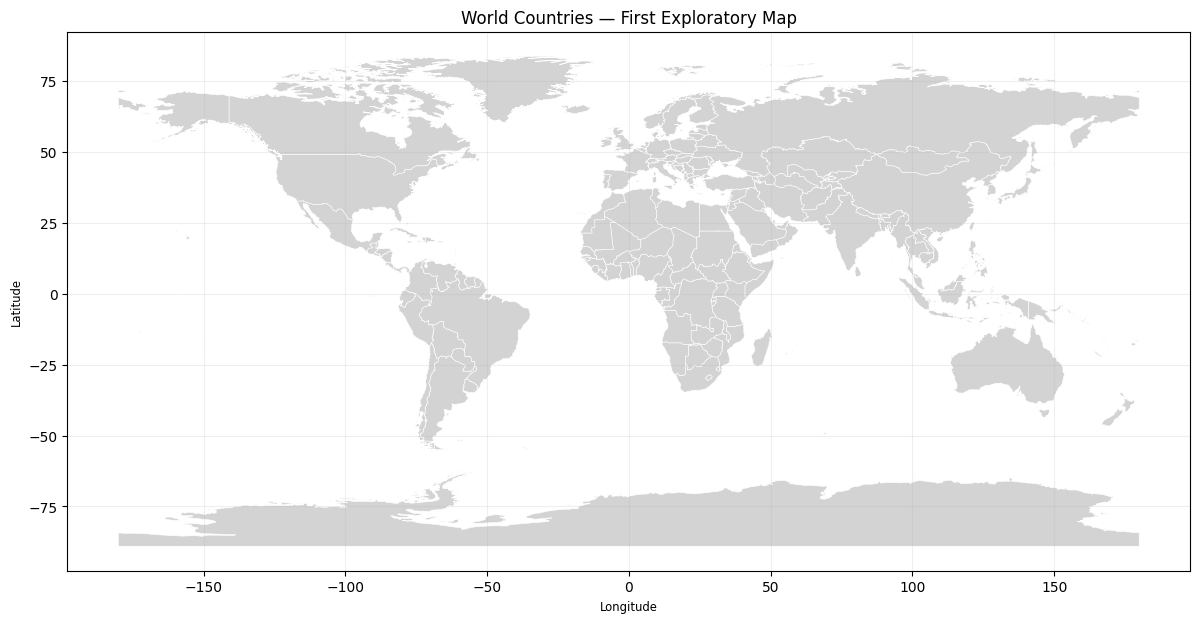

In [18]:
fig, ax = plt.subplots(figsize=(15, 7))

world.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.4
)

ax.set_title("World Countries — First Exploratory Map")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)

plt.show()

## 19. Map types ที่ควรรู้จัก

### Reference map
ใช้บอกตำแหน่งและขอบเขต เช่น แผนที่ประเทศ จังหวัด ถนน

### Thematic map
แสดง “เรื่องหนึ่งเรื่อง” เช่น ทวีป ประเภทที่ดิน ปริมาณฝน

### Categorical thematic map
ใช้สีแยก **กลุ่ม/ประเภท** เช่น `CONTINENT`

### Choropleth map
ใช้สีหรือความเข้มแทน **ค่าตัวเลขของพื้นที่**

แนวคิด:

$$
Color_i=f(x_i)
$$

เช่น population density, rainfall, percentage หรือ land rank

> ชื่อประเทศ `COUNTRY` เป็น categorical/name attribute  
> จึงไม่ควรตีความว่าเป็นค่าปริมาณสำหรับ choropleth

## 20. Categorical thematic map — ทวีป

ถ้ามี field `CONTINENT` เราจะใช้เพื่อแยกสีแต่ละทวีป

In [19]:
if continent_col:
    fig, ax = plt.subplots(figsize=(15, 8))

    world.plot(
        ax=ax,
        column=continent_col,
        categorical=True,
        legend=True,
        edgecolor="white",
        linewidth=0.3
    )

    ax.set_title("World Countries by Continent — Categorical Thematic Map")
    ax.set_axis_off()
    plt.show()

    print("Continent categories:")
    display(world[continent_col].value_counts())
else:
    print("Dataset นี้ไม่มี field ทวีป จึงข้าม categorical continent map")

Dataset นี้ไม่มี field ทวีป จึงข้าม categorical continent map


## 21. Choropleth / Graduated-color map

ถ้ามี `LAND_RANK` เราจะใช้เป็นตัวอย่างของ numeric/ordinal attribute

> จุดประสงค์ของ cell นี้คือเรียนรู้ว่า **ชนิดของ attribute มีผลต่อชนิดของแผนที่**

In [20]:
if rank_col:
    fig, ax = plt.subplots(figsize=(15, 8))

    world.plot(
        ax=ax,
        column=rank_col,
        cmap="viridis_r",
        legend=True,
        edgecolor="white",
        linewidth=0.3,
        missing_kwds={"color": "lightgray"}
    )

    ax.set_title(f"World Countries by {rank_col} — Graduated-color Map")
    ax.set_axis_off()
    plt.show()
else:
    print("ไม่พบ numeric land-rank field — เก็บ choropleth แบบเต็มไว้เรียนใน Notebook 03")

ไม่พบ numeric land-rank field — เก็บ choropleth แบบเต็มไว้เรียนใน Notebook 03


## 22. Attribute Query — เลือกประเทศไทย

Attribute query หมายถึงการเลือกแถวที่ตรงกับเงื่อนไข

แนวคิด:

```text
SELECT feature
WHERE attribute satisfies condition
```

ใน Pandas / GeoPandas เราใช้ Boolean condition

In [21]:
country_text = world[country_col].astype(str).str.strip()

thailand = world[
    country_text.str.casefold() == "thailand"
].copy()

print("Thailand features found:", len(thailand))
display(thailand[cols_to_show])

Thailand features found: 1


,COUNTRY
223,Thailand


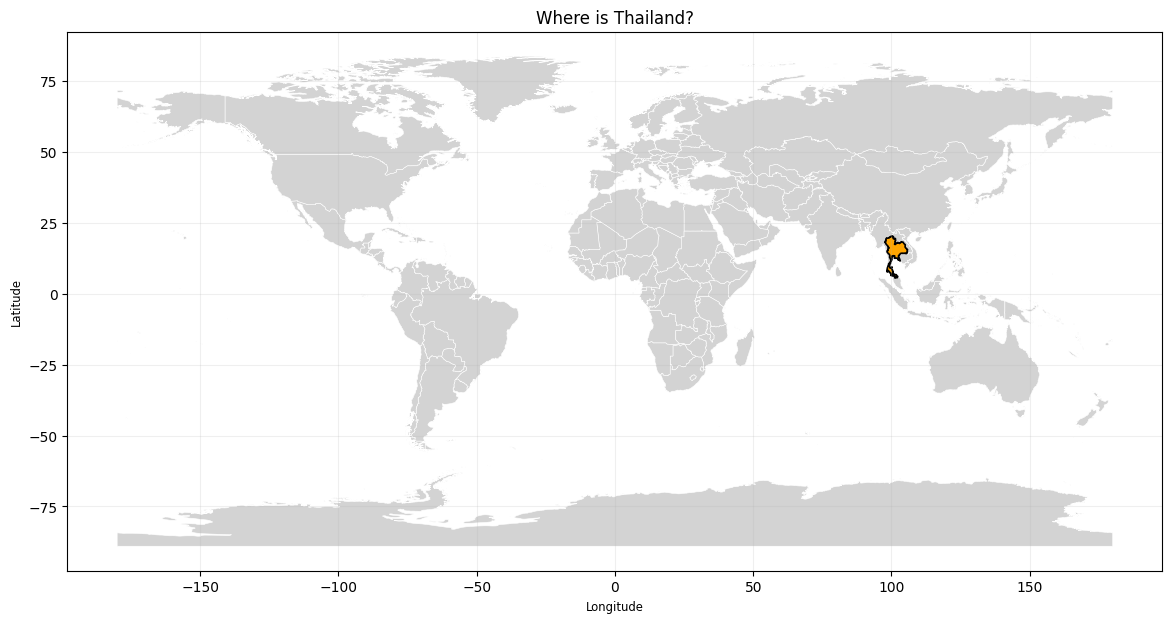

In [22]:
fig, ax = plt.subplots(figsize=(15, 7))

world.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="white",
    linewidth=0.4
)

thailand.plot(
    ax=ax,
    facecolor="orange",
    edgecolor="black",
    linewidth=1.2
)

ax.set_title("Where is Thailand?")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)

plt.show()

## 23. Label จาก geometry

สำหรับ polygon ที่ซับซ้อน `centroid` อาจอยู่นอก polygon ได้ในบางกรณี  
สำหรับงาน label เราสามารถใช้ `representative_point()` ซึ่งคืนจุดที่อยู่ภายใน geometry

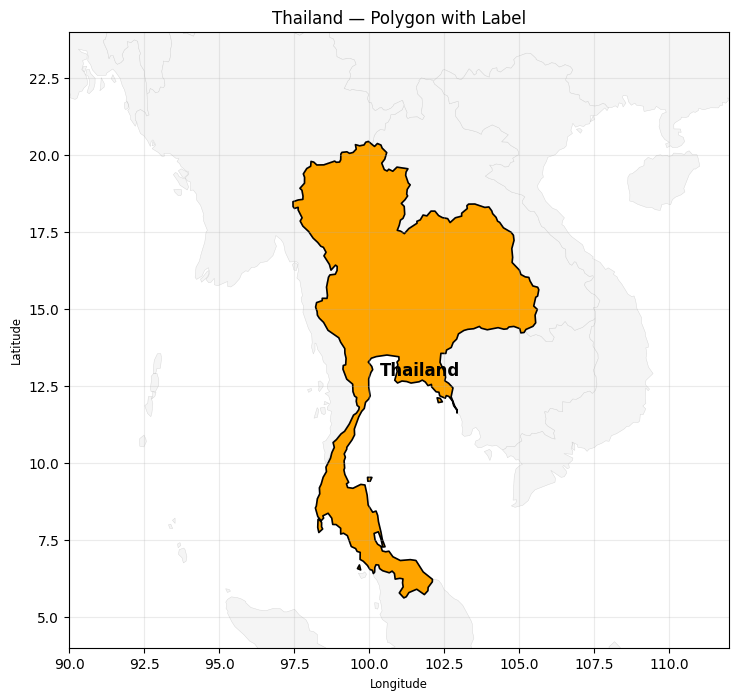

In [23]:
if not thailand.empty:
    label_points = thailand.geometry.representative_point()

    fig, ax = plt.subplots(figsize=(10, 8))

    world.plot(ax=ax, facecolor="whitesmoke", edgecolor="lightgray", linewidth=0.3)
    thailand.plot(ax=ax, facecolor="orange", edgecolor="black", linewidth=1.2)

    for idx, pt in label_points.items():
        label = thailand.loc[idx, country_col]
        ax.text(
            pt.x,
            pt.y,
            str(label),
            fontsize=12,
            ha="center",
            va="center",
            fontweight="bold"
        )

    ax.set_xlim(90, 112)
    ax.set_ylim(4, 24)
    ax.set_title("Thailand — Polygon with Label")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25)

    plt.show()

## 24. Query operators ที่ใช้บ่อย

```python
==          เท่ากับ
!=          ไม่เท่ากับ
> < >= <=   เปรียบเทียบตัวเลข
.isin()     อยู่ในรายการหรือไม่
.str.contains()  ค้นข้อความ
```

ลองเลือกหลายประเทศพร้อมกัน

In [24]:
selected_names = [
    "Thailand",
    "Japan",
    "Vietnam"
]

selected = world[
    world[country_col].astype(str).isin(selected_names)
].copy()

display(selected[[country_col, "geometry"]].head())
print("Selected features:", len(selected))

,COUNTRY,geometry
113,Japan,"MULTIPOLYGON (((134.29938 34.70412, 134.09912 ..."
223,Thailand,"MULTIPOLYGON (((100.12711 6.42495, 100.09018 6..."
246,Vietnam,"MULTIPOLYGON (((104.44533 10.42274, 104.54857 ..."


Selected features: 3


### Try it

เพิ่ม `"Malaysia"` และ `"Indonesia"` ลงใน `selected_names` แล้วรัน cell ก่อนหน้าใหม่

สังเกตว่า

```text
การแก้ list
→ เปลี่ยน query
→ เปลี่ยนผลลัพธ์ GIS
```

## 25. Query Asia

ถ้ามี field `CONTINENT` เราจะ query ทวีปเอเชียจาก attribute โดยตรง

In [25]:
if continent_col:
    continent_text = world[continent_col].astype(str).str.strip().str.casefold()

    asia = world[
        continent_text == "asia"
    ].copy()

    print("Asia features:", len(asia))

    fig, ax = plt.subplots(figsize=(12, 9))
    asia.plot(ax=ax, facecolor="lightsteelblue", edgecolor="white", linewidth=0.6)

    ax.set_title("Asia")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25)

    plt.show()
else:
    asia = gpd.GeoDataFrame(columns=world.columns, geometry="geometry", crs=world.crs)
    print("ไม่มี field CONTINENT จึงไม่ทำ attribute query Asia")

ไม่มี field CONTINENT จึงไม่ทำ attribute query Asia


## 26. Query Southeast Asia

ข้อมูลชื่อประเทศจากแต่ละแหล่งอาจเขียนต่างกันเล็กน้อย เช่น `Laos` / `Lao...` หรือ `Vietnam` / `Viet Nam`

ดังนั้นสำหรับการสอน เราจะใช้ keyword matching อย่างระมัดระวัง

In [26]:
sea_patterns = [
    "Thailand",
    "Myanmar",
    "Burma",
    "Laos",
    "Lao",
    "Cambodia",
    "Vietnam",
    "Viet Nam",
    "Malaysia",
    "Singapore",
    "Indonesia",
    "Philippines",
    "Brunei",
    "Timor"
]

pattern = "|".join(sea_patterns)

sea = world[
    world[country_col]
        .astype(str)
        .str.contains(pattern, case=False, regex=True, na=False)
].copy()

print("Southeast Asia features:", len(sea))
display(sea[[country_col]])

Southeast Asia features: 11


,COUNTRY
34,Brunei Darussalam
39,Cambodia
105,Indonesia
122,Laos
134,Malaysia
152,Myanmar
176,Philippines
203,Singapore
223,Thailand
224,Timor-Leste


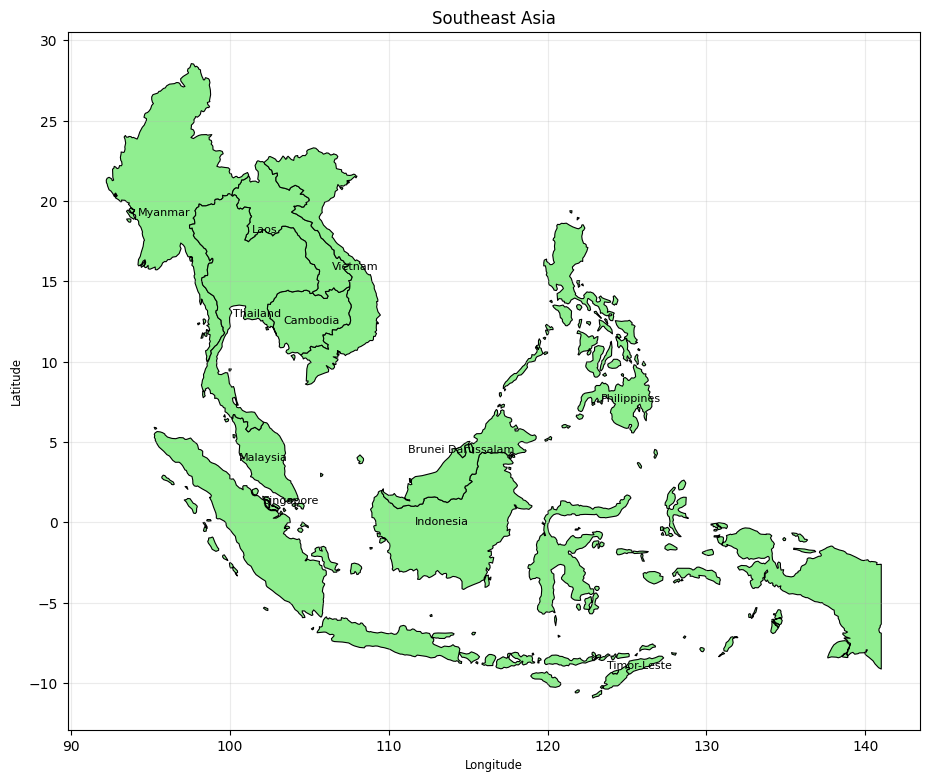

In [27]:
fig, ax = plt.subplots(figsize=(11, 10))

sea.plot(
    ax=ax,
    facecolor="lightgreen",
    edgecolor="black",
    linewidth=0.8
)

label_points = sea.geometry.representative_point()

for idx, pt in label_points.items():
    ax.text(
        pt.x,
        pt.y,
        str(sea.loc[idx, country_col]),
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title("Southeast Asia")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.25)

plt.show()

## 27. Static map vs Interactive map

| Static map | Interactive map |
|---|---|
| เหมาะกับรายงาน/บทความ | เหมาะกับการสำรวจข้อมูล |
| PNG / PDF | HTML |
| extent คงที่ | zoom / pan |
| symbol คงที่ | tooltip / popup |
| เหมาะกับ publication figure | เหมาะกับ query และ exploration |

แนวทางของชุดการสอนนี้:

> **Explore with Folium → Communicate with a publication map**

## 28. Interactive Map ด้วย Folium

Folium ใช้ Web Map ที่เหมาะกับพิกัด longitude / latitude  
เพื่อความปลอดภัย เราจะแปลงข้อมูลสำหรับ web map เป็น EPSG:4326 ก่อน

In [29]:
import folium
import xyzservices.providers as xyz

# ---------------------------------------------------------
# Prepare data for web mapping
# ---------------------------------------------------------
sea_web = sea.to_crs("EPSG:4326")
thailand_web = thailand.to_crs("EPSG:4326")


# ---------------------------------------------------------
# 1. Create Folium map WITHOUT the default OpenStreetMap
# ---------------------------------------------------------
m = folium.Map(
    location=[13.5, 105.0],
    zoom_start=4,
    tiles=None,
    control_scale=True
)


# ---------------------------------------------------------
# 2. Add OpenTopoMap as the basemap
# ---------------------------------------------------------
basemap = xyz.OpenTopoMap

folium.TileLayer(
    tiles=basemap.build_url(),
    attr=basemap.html_attribution,
    name="OpenTopoMap",
    overlay=False,
    control=True,
    show=True
).add_to(m)


# ---------------------------------------------------------
# 3. Add Southeast Asia polygons
# ---------------------------------------------------------
folium.GeoJson(
    sea_web,
    name="Southeast Asia",
    style_function=lambda feature: {
        "fillColor": "#b8e6b8",
        "color": "#333333",
        "weight": 1,
        "fillOpacity": 0.55,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[country_col],
        aliases=["Country:"]
    )
).add_to(m)


# ---------------------------------------------------------
# 4. Highlight Thailand
# ---------------------------------------------------------
if not thailand_web.empty:

    folium.GeoJson(
        thailand_web,
        name="Thailand",
        style_function=lambda feature: {
            "fillColor": "#ff9800",
            "color": "#000000",
            "weight": 2,
            "fillOpacity": 0.75,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=[country_col],
            aliases=["Selected country:"]
        )
    ).add_to(m)


# ---------------------------------------------------------
# 5. Layer control
# ---------------------------------------------------------
folium.LayerControl(
    collapsed=False
).add_to(m)


# Display map
m

## 29. Publication-quality static map

แผนที่สำหรับรายงานหรือบทความควรมีองค์ประกอบสำคัญ เช่น

- Title
- Map body
- Labels
- Legend
- North arrow
- Scale bar
- Numeric scale
- Coordinate labels / grid
- Data source
- CRS

### หมายเหตุเรื่องมาตราส่วน

สำหรับแผนที่ดิจิทัล numeric scale เช่น `1 : 25,000,000` จะถูกต้องเฉพาะเมื่อรูปถูกใช้ที่ขนาดเดิม  
เมื่อรูปถูก resize ค่า representative fraction เปลี่ยนได้

ดังนั้นเราจะระบุว่าเป็น **Approximate numeric scale at map center**

In [30]:
# ฟังก์ชันช่วยทำองค์ประกอบแผนที่
GEOD = Geod(ellps="WGS84")

def add_north_arrow(ax, x=0.94, y=0.18, size=0.10):
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=1.5,
            color="black"
        )
    )

def choose_scale_km(width_km):
    candidates = np.array([
        10, 20, 50, 100, 200, 500,
        1000, 2000, 5000
    ])
    target = width_km / 4
    return int(candidates[np.argmin(np.abs(candidates - target))])

def add_geodesic_scalebar(ax):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    center_lat = (ymin + ymax) / 2
    _, _, width_m = GEOD.inv(xmin, center_lat, xmax, center_lat)
    width_km = abs(width_m) / 1000

    scale_km = choose_scale_km(width_km)

    x0 = xmin + 0.07 * (xmax - xmin)
    y0 = ymin + 0.08 * (ymax - ymin)

    lon1, lat1, _ = GEOD.fwd(
        x0,
        y0,
        90,
        scale_km * 1000
    )

    ax.plot(
        [x0, lon1],
        [y0, lat1],
        color="black",
        linewidth=3,
        solid_capstyle="butt"
    )

    ax.plot(
        [x0, x0],
        [y0 - 0.003*(ymax-ymin), y0 + 0.003*(ymax-ymin)],
        color="black",
        linewidth=1.5
    )

    ax.plot(
        [lon1, lon1],
        [lat1 - 0.003*(ymax-ymin), lat1 + 0.003*(ymax-ymin)],
        color="black",
        linewidth=1.5
    )

    ax.text(
        (x0 + lon1) / 2,
        y0 + 0.018 * (ymax-ymin),
        f"{scale_km:,} km",
        ha="center",
        va="bottom",
        fontsize=9
    )

def approximate_numeric_scale(fig, ax):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    center_lat = (ymin + ymax) / 2

    _, _, ground_width_m = GEOD.inv(
        xmin, center_lat, xmax, center_lat
    )
    ground_width_m = abs(ground_width_m)

    bbox = ax.get_position()
    map_width_inch = fig.get_figwidth() * bbox.width
    map_width_m = map_width_inch * 0.0254

    if map_width_m == 0:
        return None

    denominator = ground_width_m / map_width_m
    return int(round(denominator, -4))

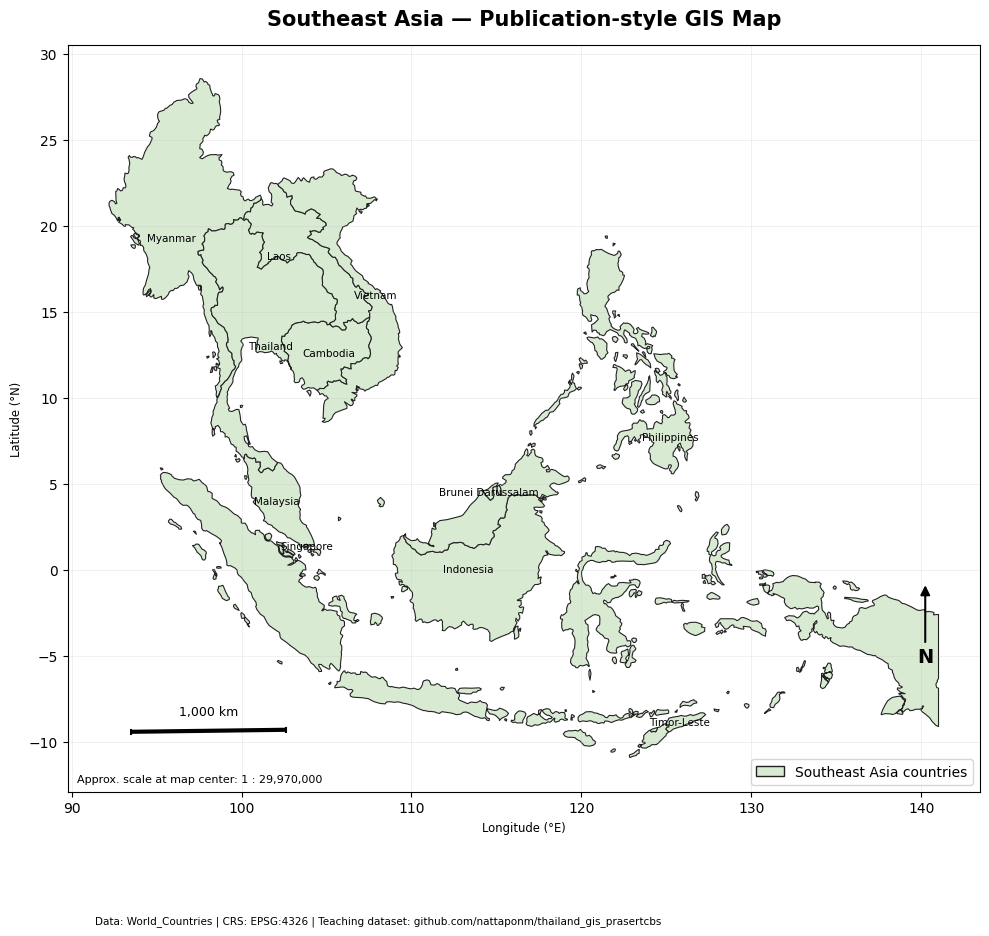

In [31]:
# แผนที่ Southeast Asia สำหรับใช้เป็นต้นแบบ publication figure
sea_pub = sea.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 10))

sea_pub.plot(
    ax=ax,
    facecolor="#d9ead3",
    edgecolor="#222222",
    linewidth=0.8
)

# Labels
label_points = sea_pub.geometry.representative_point()

for idx, pt in label_points.items():
    ax.text(
        pt.x,
        pt.y,
        str(sea_pub.loc[idx, country_col]),
        fontsize=7.5,
        ha="center",
        va="center"
    )

# Title + axes
ax.set_title(
    "Southeast Asia — Publication-style GIS Map",
    fontsize=15,
    fontweight="bold",
    pad=14
)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.grid(alpha=0.22, linewidth=0.6)

# Map elements
add_north_arrow(ax)
add_geodesic_scalebar(ax)

legend_patch = mpatches.Patch(
    facecolor="#d9ead3",
    edgecolor="#222222",
    label="Southeast Asia countries"
)
ax.legend(handles=[legend_patch], loc="lower right")

# Approximate numeric scale
scale_n = approximate_numeric_scale(fig, ax)

if scale_n:
    ax.text(
        0.01,
        0.01,
        f"Approx. scale at map center: 1 : {scale_n:,}",
        transform=ax.transAxes,
        fontsize=8,
        va="bottom"
    )

# Source and CRS
fig.text(
    0.10,
    0.015,
    "Data: World_Countries | CRS: EPSG:4326 | "
    "Teaching dataset: github.com/nattaponm/thailand_gis_prasertcbs",
    fontsize=7.5
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### ข้อสังเกต

แผนที่นี้ใช้ geographic coordinates และ scale bar คำนวณแบบ geodesic ที่ตำแหน่งหนึ่งของแผนที่

ใน Notebook 02 เราจะเรียนว่า

- projection ทำให้ shape / area / distance เปลี่ยนอย่างไร
- numeric scale มีเงื่อนไขอะไร
- ทำไม analysis CRS และ display CRS อาจไม่เหมือนกัน

## 30. Export แผนที่เป็น PNG 300 dpi

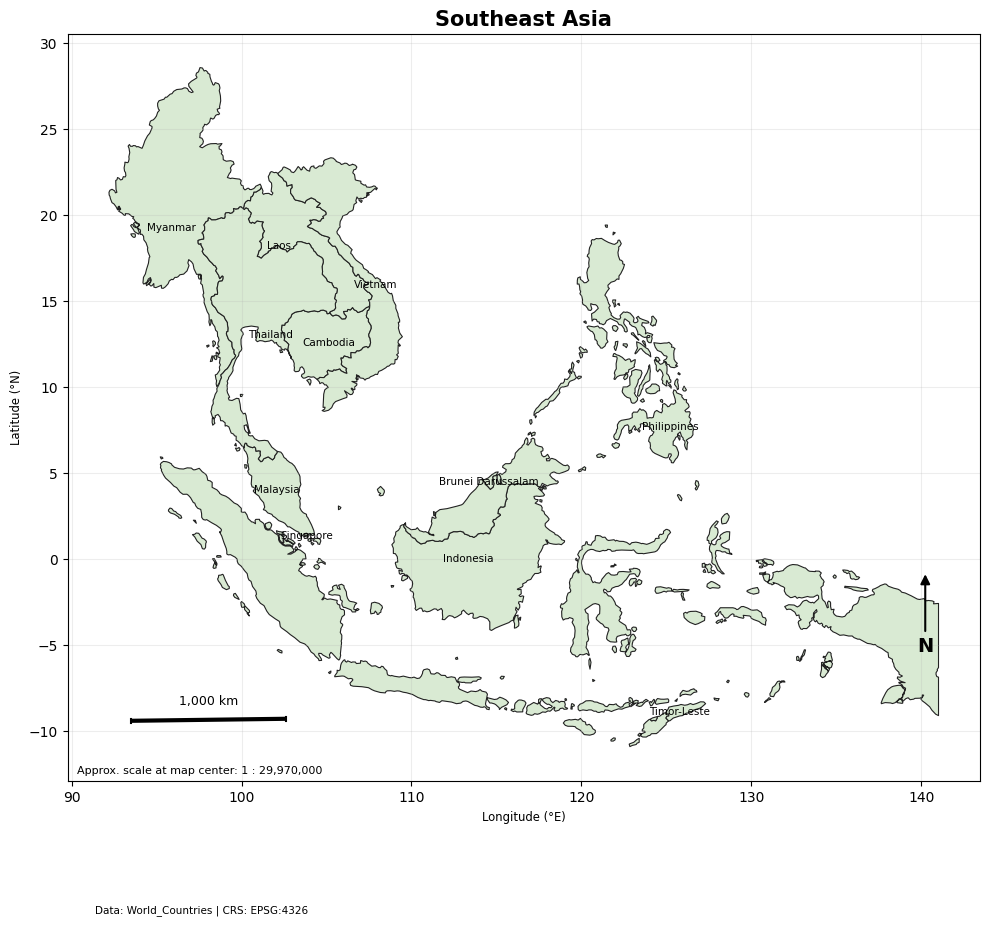

Saved: /content/gis01_outputs/maps/southeast_asia_map_300dpi.png


In [32]:
maps_dir = OUTPUT_DIR / "maps"
maps_dir.mkdir(parents=True, exist_ok=True)

png_path = maps_dir / "southeast_asia_map_300dpi.png"

fig, ax = plt.subplots(figsize=(10, 10))

sea_pub.plot(
    ax=ax,
    facecolor="#d9ead3",
    edgecolor="#222222",
    linewidth=0.8
)

label_points = sea_pub.geometry.representative_point()

for idx, pt in label_points.items():
    ax.text(
        pt.x,
        pt.y,
        str(sea_pub.loc[idx, country_col]),
        fontsize=7.5,
        ha="center",
        va="center"
    )

ax.set_title(
    "Southeast Asia",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.grid(alpha=0.22)

add_north_arrow(ax)
add_geodesic_scalebar(ax)

scale_n = approximate_numeric_scale(fig, ax)
if scale_n:
    ax.text(
        0.01,
        0.01,
        f"Approx. scale at map center: 1 : {scale_n:,}",
        transform=ax.transAxes,
        fontsize=8
    )

fig.text(
    0.10,
    0.015,
    "Data: World_Countries | CRS: EPSG:4326",
    fontsize=7.5
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", png_path)

## 31. Export เป็น Shapefile

จำไว้ว่า Shapefile เป็นชุดหลายไฟล์  
เราจะสร้าง folder แล้ว ZIP ทั้งชุดเพื่อให้ดาวน์โหลด/เปิดใน QGIS ได้สะดวก

In [33]:
shp_parent = OUTPUT_DIR / "shapefiles"
shp_folder = shp_parent / "southeast_asia"

if shp_folder.exists():
    shutil.rmtree(shp_folder)

shp_folder.mkdir(parents=True, exist_ok=True)

shp_out = shp_folder / "southeast_asia.shp"

sea.to_file(
    shp_out,
    driver="ESRI Shapefile",
    encoding="UTF-8"
)

zip_base = shp_parent / "southeast_asia"
zip_created = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=shp_folder
)

print("Shapefile folder:", shp_folder)
print("ZIP for QGIS:", zip_created)

Shapefile folder: /content/gis01_outputs/shapefiles/southeast_asia
ZIP for QGIS: /content/gis01_outputs/shapefiles/southeast_asia.zip


## 32. Export เป็น GeoPackage

GeoPackage (`.gpkg`) เป็น format ที่ทันสมัยกว่า Shapefile ในหลายกรณี

ข้อดี:

- เป็นไฟล์เดียว
- เก็บหลาย layers ได้
- รองรับชื่อ field ได้ดีกว่า Shapefile
- เหมาะกับ UTF-8 / ภาษาไทย

In [34]:
gpkg_dir = OUTPUT_DIR / "geopackages"
gpkg_dir.mkdir(parents=True, exist_ok=True)

gpkg_path = gpkg_dir / "southeast_asia.gpkg"

if gpkg_path.exists():
    gpkg_path.unlink()

sea.to_file(
    gpkg_path,
    layer="southeast_asia",
    driver="GPKG"
)

print("Saved:", gpkg_path)

Saved: /content/gis01_outputs/geopackages/southeast_asia.gpkg


## 33. Save Folium Map เป็น HTML

In [35]:
html_dir = OUTPUT_DIR / "html"
html_dir.mkdir(parents=True, exist_ok=True)

html_path = html_dir / "southeast_asia_interactive.html"

m.save(html_path)

print("Saved:", html_path)

Saved: /content/gis01_outputs/html/southeast_asia_interactive.html


## 34. ตรวจ outputs ทั้งหมด

In [36]:
print("OUTPUTS")

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        print(f"{p.relative_to(OUTPUT_DIR)}  ({size_kb:,.1f} KB)")

OUTPUTS
geopackages/southeast_asia.gpkg  (188.0 KB)
html/southeast_asia_interactive.html  (231.7 KB)
maps/southeast_asia_map_300dpi.png  (673.8 KB)
shapefiles/southeast_asia/southeast_asia.cpg  (0.0 KB)
shapefiles/southeast_asia/southeast_asia.dbf  (3.6 KB)
shapefiles/southeast_asia/southeast_asia.prj  (0.1 KB)
shapefiles/southeast_asia/southeast_asia.shp  (79.9 KB)
shapefiles/southeast_asia/southeast_asia.shx  (0.2 KB)
shapefiles/southeast_asia.zip  (70.7 KB)


## 35. Optional — ดาวน์โหลดไฟล์จาก Colab

เปิด comment เฉพาะไฟล์ที่ต้องการดาวน์โหลด

```python
from google.colab import files

files.download("/content/gis01_outputs/maps/southeast_asia_map_300dpi.png")
files.download("/content/gis01_outputs/shapefiles/southeast_asia.zip")
files.download("/content/gis01_outputs/geopackages/southeast_asia.gpkg")
files.download("/content/gis01_outputs/html/southeast_asia_interactive.html")
```

# Concept Check

ลองตอบโดยไม่ย้อนดู code

1. GeoDataFrame ต่างจาก DataFrame อย่างไร?
2. `geometry` มีหน้าที่อะไร?
3. CRS บอกอะไรเรา?
4. EPSG:4326 มีลักษณะอย่างไร?
5. Point, LineString และ Polygon ใช้แทนสิ่งใดได้บ้าง?
6. `world.total_bounds` บอกอะไร?
7. Attribute query คืออะไร?
8. Categorical thematic map ต่างจาก choropleth อย่างไร?
9. Folium ต่างจาก static Matplotlib map อย่างไร?
10. ทำไมเรายังไม่ควรคำนวณพื้นที่ด้วย `.area` โดยไม่ตรวจ CRS?

# Exercise 1 — Query ประเทศของคุณเอง

เลือกประเทศ 1 ประเทศ เช่น

```text
Japan
Vietnam
Australia
France
Brazil
```

ให้ทำตามขั้นตอน:

```text
1. Query ประเทศ
2. แสดง attribute
3. Highlight บนแผนที่โลก
4. ใส่ label
5. แสดงใน Folium
```

### Code starter

```python
my_country = "Japan"

result = world[
    world[country_col].astype(str).str.casefold()
    == my_country.casefold()
].copy()

result
```

# Exercise 2 — Query หลายประเทศและ Export

เลือก 5 ประเทศที่นิสิตสนใจ แล้ว

1. Query ด้วย `.isin()`
2. Plot เป็นแผนที่
3. เพิ่ม labels
4. Export PNG 300 dpi
5. Export Shapefile ZIP
6. Export GeoPackage
7. Export Folium HTML

> **คำถาม:** Output แบบใดเหมาะกับ QGIS มากที่สุดในสถานการณ์ของคุณ และเพราะอะไร?

# Exercise 3 — GIS reasoning

ตอบคำถามสั้น ๆ:

> ถ้า `world.crs` เป็น EPSG:4326 เหตุใดเราไม่ควรใช้

```python
world.area
```

แล้วรายงานผลว่าเป็น `km²` ทันที?

Hint:

```text
CRS
→ coordinate units
→ measurement units
```

# MSc Challenge

พิจารณาคำถาม:

1. แผนที่โลกใน EPSG:4326 และ Web Mercator แสดงรูปร่างพื้นที่ต่างกันหรือไม่?
2. ถ้า Greenland ดูใหญ่ขึ้นบนแผนที่ ค่าพื้นที่จริงของ Greenland เปลี่ยนหรือไม่?
3. ถ้าต้องการเปรียบเทียบพื้นที่ประเทศทั่วโลก ควรพิจารณา projection ประเภทใด?
4. ทำไม **display CRS** และ **analysis CRS** ไม่จำเป็นต้องเป็น CRS เดียวกัน?

ยังไม่ต้องเขียน code ทั้งหมด — ให้เขียนสมมติฐานก่อน แล้วเราจะทดลองใน Notebook 02

# Summary

Notebook นี้เริ่มจากคำถามพื้นฐานที่สุด:

> **ข้อมูล GIS นี้คืออะไร อยู่ที่ไหน และมีอะไรอยู่ในตาราง?**

สิ่งที่ได้เรียน:

$$
\boxed{
\text{Inspect}
\rightarrow
\text{Query}
\rightarrow
\text{Map}
\rightarrow
\text{Export}
}
$$

และแนวคิดสำคัญที่สุดคือ

$$
GeoDataFrame = DataFrame + Geometry + CRS
$$

## ต่อไป: Notebook 02

**CRS, Projection, Scale & Cartographic Mapping**

คำถามเปิดบทถัดไป:

> แผนที่ที่เราเพิ่งสร้าง “ดูถูกต้อง” แต่เราสามารถใช้ CRS ปัจจุบันวัดพื้นที่ ระยะทาง และ buffer ได้อย่างถูกต้องแล้วหรือยัง?